In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:42301")
client

<Client: 'tcp://127.0.0.1:42301' processes=9 threads=72, memory=136.41 GiB>

In [2]:
import xarray as xr
import numpy as np
import os.path as op
import tripyview as tpv
import gsw
import matplotlib.pyplot as plt

# xr.set_options(keep_attrs=True)
# do_parallel       = True
# parallel_nprc     = 16   # number of dask workers
# parallel_nprc_bin = 8   # number of processor used to parallize the binning loop
# parallel_tmem     = 256   # max. available RAM

%matplotlib inline

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:8: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
ddir = "/work/uo0119/a270067/runtime/awicm3-v3.1/"
sdir = "/scratch/b/b383315/"
wdir = "/work/ba1254/b383315/fesom2/next/"

In [5]:
NXX = 50
ds1 = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/ke_adv_u.fesom.2090.nc"
                              % NXX),
                     chunks={"nz1":1,"x":100000}
                    )
ds = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/w.fesom.2090.nc"
                             % NXX),
                     chunks={"nz":1,"x":100000}
                    )
ds1, ds

(<xarray.Dataset> Size: 58GB
 Dimensions:   (time: 12, nz1: 47, x: 25742475)
 Coordinates:
   * time      (time) datetime64[ns] 96B 2090-01-31T23:57:00 ... 2090-12-31T23...
   * nz1       (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
 Dimensions without coordinates: x
 Data variables:
     ke_adv_u  (time, nz1, x) float32 58GB dask.array<chunksize=(1, 1, 100000), meta=np.ndarray>
 Attributes: (12/20)
     CDI:                           Climate Data Interface version 2.0.5 (http...
     Conventions:                   CF-1.6
     FESOM_model:                   FESOM2
     FESOM_website:                 fesom.de
     FESOM_git_SHA:                 e23bc823
     FESOM_MeshPath:                /work/ab0995/a270067/fesom2/next/mesh/
     ...                            ...
     FESOM_evp_rheol_steps:         120
     FESOM_opt_visc:                7
     FESOM_use_wsplit:              -1
     FESOM_autorotate_back_to_geo:  0
     history:                       Thu Aug 07 1

In [6]:
iz2000 = 31
iz4300 = 40
dz = xr.DataArray(np.diff(ds.nz), dims=["nz1"],
                  coords={"nz1":ds1.nz1}
                 ).isel(nz1=slice(None,iz4300))
dz

<xarray.DataArray (nz1: 40)> Size: 320B
array([  5.,   5.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        15.,  20.,  25.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 170., 200., 220., 230., 250., 250.,
       250., 250., 250., 250., 250., 250., 250.])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03

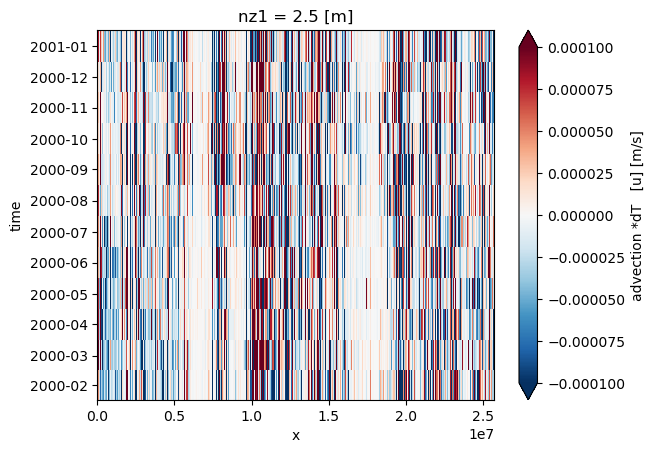

In [7]:
ds.ke_adv_u.isel(nz1=0).plot(vmax=1e-4, rasterized=True)

In [7]:
NXX = 48
nz = 47

plt_contb = True        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tcf'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, -30] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
# proj = 'rob'               # Robinson projection
proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 2                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 2                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cmin      = None
cmax      = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

In [ ]:
dt = 180. # 3 minutes

mesh_path = '/work/ab0995/a270067/fesom2/next/mesh/'
mesh = tpv.load_mesh_fesom2(mesh_path, do_rot='None', focus=0, 
                            do_info=True, do_pickle=False
                           )
mesh

 > load mesh from *.out files: /work/ab0995/a270067/fesom2/next/mesh
 > load e_area from fesom.mesh.diag.nc
 > load n_area from fesom.mesh.diag.nc
 > compute lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_pbnd.shp


In [ ]:
ystart = 2090
NXX = 50

for yy in range(ystart,2101):
    
    p_path = op.join(ddir,'N%02d/outdata/fesom/ke_PFULL.fesom.%4d.nc'
                      % (NXX,yy))
    dw_path = op.join(ddir,'N%02d/outdata/fesom/ke_dW.fesom.%4d.nc'
                      % (NXX,yy))
    pdw_path = op.join(ddir,'N%02d/outdata/fesom/W_x_RHO.fesom.%4d.nc'
                      % (NXX,yy))
    h_path = op.join(ddir,'N%02d/outdata/fesom/MLD3.fesom.%4d.nc'
                      % (NXX,yy))
        
    if yy == ystart:
        months = range(1,13)
    else:
        months = range(1,13)
    
    for mm in months:
        mld = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                  vname="MLD3", do_info=False,
                                  year=yy, mon=mm
                                 ).chunk({'nod2':100000})
        for i in range(iz4300):
            if i == 0:
                p = tpv.load_data_fesom2(mesh, p_path, do_filename=True,
                                          vname="ke_PFULL", do_info=False,
                                          depth=[ds1.nz1[i].values], 
                                         year=yy, mon=mm
                                         ).chunk({'nod2':100000})
                dw = tpv.load_data_fesom2(mesh, dw_path, do_filename=True,
                                          vname="ke_dW", do_info=False,
                                          depth=[ds1.nz1[i].values], 
                                          year=yy, mon=mm
                                         ).chunk({'nod2':100000})
                pdw = tpv.load_data_fesom2(mesh, pdw_path, do_filename=True,
                                          vname="ke_wrho", do_info=False,
                                          depth=[ds1.nz1[i].values], 
                                           year=yy, mon=mm
                                         ).chunk({'nod2':100000})
            else:
                p = xr.concat([p, 
                              tpv.load_data_fesom2(mesh, p_path, do_filename=True,
                                                  vname="ke_PFULL", do_info=False,
                                                  depth=[ds1.nz1[i].values], 
                                                   year=yy, mon=mm
                                     ).chunk({'nod2':100000})
                              ], "nz1")
                dw = xr.concat([dw, 
                              tpv.load_data_fesom2(mesh, dw_path, do_filename=True,
                                                  vname="ke_dW", do_info=False,
                                                  depth=[ds1.nz1[i].values], 
                                                   year=yy, mon=mm
                                     ).chunk({'nod2':100000})
                              ], "nz1")
                pdw = xr.concat([pdw, 
                              tpv.load_data_fesom2(mesh, pdw_path, do_filename=True,
                                                  vname="ke_wrho", do_info=False,
                                                  depth=[ds1.nz1[i].values], 
                                                   year=yy, mon=mm
                                     ).chunk({'nod2':100000})
                              ], "nz1")

        ppdwp = (pdw.W_x_RHO / dt 
                 - (p.ke_PFULL * dw.ke_dW)
                )

        ppdwpH = ((ppdwp
                   * dz
                  ).where(ppdwp.nz1<np.abs(mld.MLD3)
                         ).sum("nz1",skipna=True) 
                  / np.abs(mld.MLD3)
                 ).reset_coords(drop=True).to_dataset(name="WpRHOpH")
        print(ppdwpH)
        ppdwpH.to_zarr(op.join(wdir,"ppdwp/N%2d/ppdwp_%4d-%02d.zarr" 
                               % (NXX,yy,mm)),
                       mode="w")
        ppdwpH.close()
        p.close(), dw.close(), pdw.close(), mld.close()
        del ppdwp
        print(mm)
    print(yy)